<a href="https://colab.research.google.com/github/vignytl1-oss/data-analytics-portfolio/blob/main/StockPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

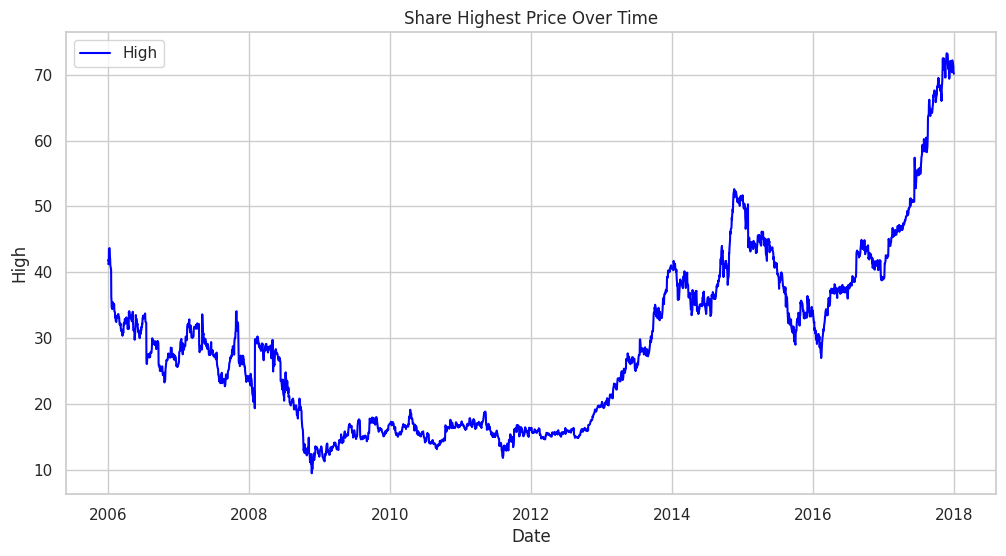

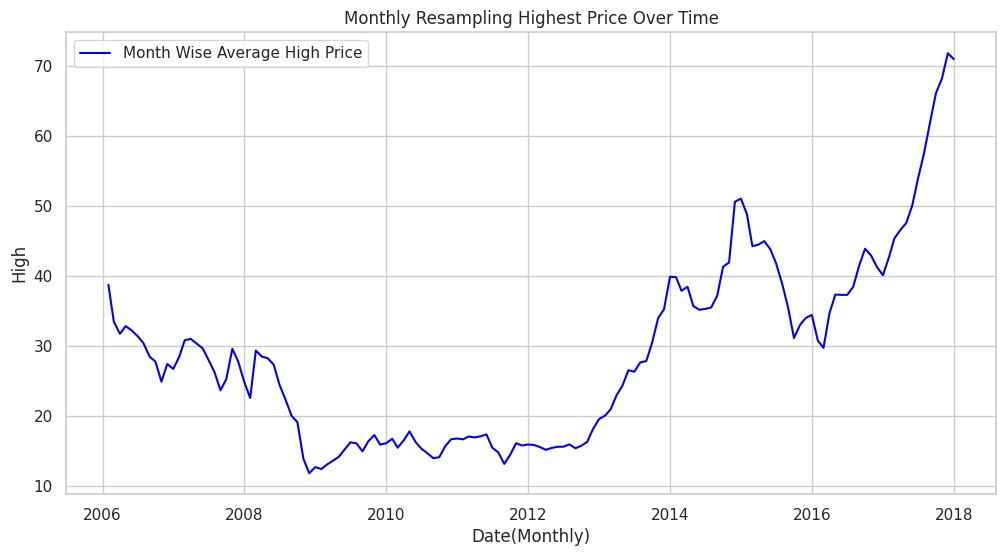

<Figure size 1200x600 with 0 Axes>

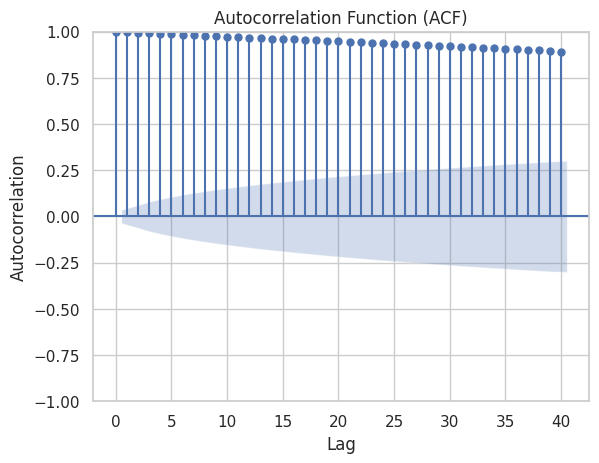

/tmp/ipykernel_1952/1590149078.py:52: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df['High'])


ADF Statistic: 0.7671404880535936
p-value: 0.9910868050318213
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


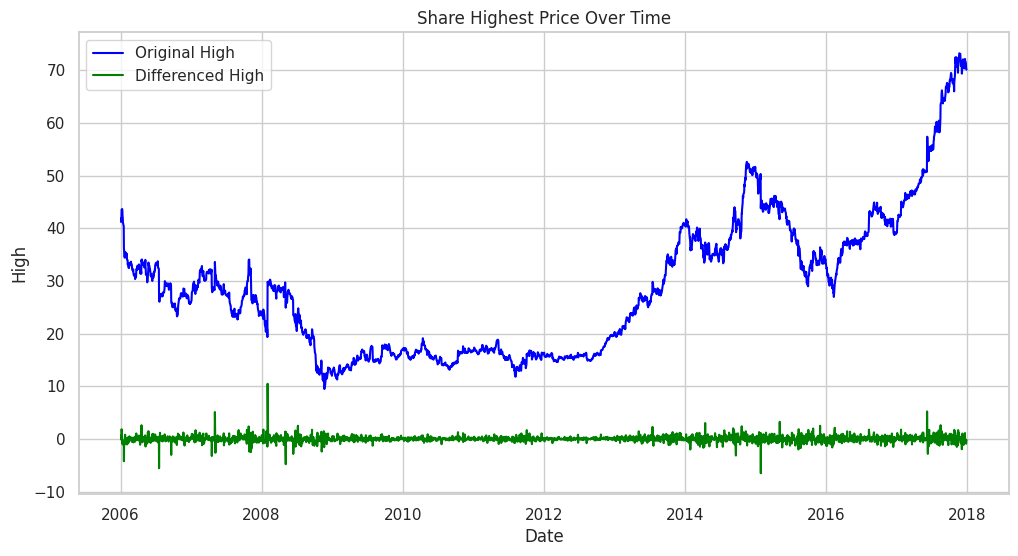

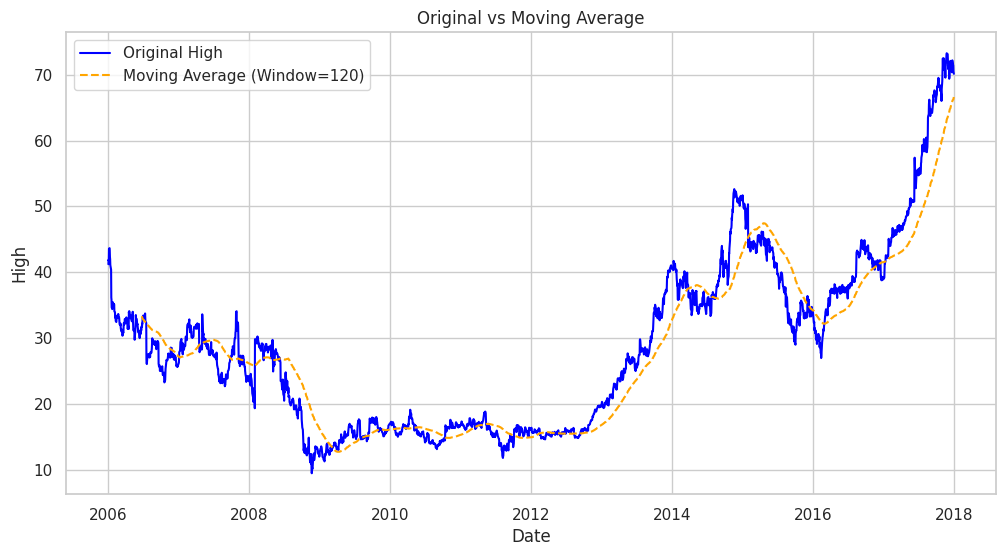

             High  high diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


,high diff
Date,
2006-01-04,0.68
2006-01-05,-0.17
2006-01-06,1.84
2006-01-09,0.09
2006-01-10,-0.32


In [9]:
import pandas as pd
import numpy as mp
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# Loading the Dataset

df = pd.read_csv("/content/stock_data.csv", parse_dates=True, index_col="Date")
df.head()

# Cleaning of Data
df.drop(columns='Unnamed: 0', inplace =True)
df.head()

# Plotting High Stock Prices
sns.set(style="whitegrid")

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x=df.index, y='High', label='High', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

# Resampling Data

df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot (data=df_resampled, x=df_resampled.index, y='High', label='Month Wise Average High Price', color='blue')
plt.xlabel('Date(Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')
plt.show()

# Detecting Seasonality with Autocorrelation
plt.figure(figsize=(12, 6))
plot_acf(df['High'], lags=40,)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF)')
plt.show()

# ADF Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Differencing

df['high diff'] = df['High'].diff()

plt.figure(figsize=(12,6))
plt.plot(df['High'], label= 'Original High', color='blue')
plt.plot(df['high diff'], label= 'Differenced High', color='green')
plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')
plt.legend()
plt.show()

# Smoothing Data
window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

df_combined = pd.concat([df['High'], df['high diff']], axis=1)
print(df_combined.head())

df.dropna(subset=['high diff'], inplace=True)
df['high diff'].head()